In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Plots will be saved to: {OUTPUT_DIR}")

Plots will be saved to: outputs


In [3]:
# Try loading the dataset from a public URL
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

try:
    df = pd.read_csv(DATA_URL)
    print(f"Dataset loaded from URL. Shape: {df.shape}")
except Exception as e:
    print(f"Could not download dataset ({e}).")
    print("Generating synthetic temperature data as fallback...")

    # Generate synthetic daily temperature data (realistic sinusoidal pattern)
    np.random.seed(42)
    dates = pd.date_range(start='1981-01-01', end='1990-12-31', freq='D')
    n = len(dates)
    # Simulate seasonal temperature pattern: base + seasonal cycle + noise
    base_temp = 11.0
    seasonal = 8.0 * np.sin(2 * np.pi * np.arange(n) / 365.25 - np.pi/2)
    noise = np.random.normal(0, 2.0, n)
    temps = base_temp + seasonal + noise

    df = pd.DataFrame({'Date': dates, 'Temp': temps})
    print(f"Synthetic dataset generated. Shape: {df.shape}")

# Display basic information
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"First 5 rows:\n{df.head()}")
print(f"\nDataset statistics:\n{df.describe()}")

# Extract the temperature values
temp_col = [c for c in df.columns if c.lower() in ['temp', 'temperature', 'minimum temperature']]
if temp_col:
    temperatures = df[temp_col[0]].values.astype(float)
else:
    # Fallback: use the last numeric column
    temperatures = df.select_dtypes(include=[np.number]).iloc[:, -1].values.astype(float)

print(f"\nTemperature series length: {len(temperatures)}")
print(f"Min: {temperatures.min():.2f}, Max: {temperatures.max():.2f}, "
      f"Mean: {temperatures.mean():.2f}")

Dataset loaded from URL. Shape: (3650, 2)

Dataset columns: ['Date', 'Temp']
First 5 rows:
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8

Dataset statistics:
              Temp
count  3650.000000
mean     11.177753
std       4.071837
min       0.000000
25%       8.300000
50%      11.000000
75%      14.000000
max      26.300000

Temperature series length: 3650
Min: 0.00, Max: 26.30, Mean: 11.18


In [4]:
# -- 4a. Normalize data using MinMaxScaler --
# LSTM works better with normalized data in [0, 1] range
scaler = MinMaxScaler(feature_range=(0, 1))
temperatures_scaled = scaler.fit_transform(temperatures.reshape(-1, 1)).flatten()
print("Data normalized using MinMaxScaler to [0, 1]")

# -- 4b. Create sliding window sequences --
def create_sequences(data, window_size):
    """
    Create input-output pairs using a sliding window approach.

    For each position i, we use [i : i+window_size] as input (X)
    and [i+window_size] as the target (y).

    Example (window_size=3):
        [1, 2, 3] -> 4
        [2, 3, 4] -> 5
        [3, 4, 5] -> 6

    Args:
        data: 1D array of time-series values
        window_size: Number of past time steps to use as input

    Returns:
        X: Array of shape (n_samples, window_size, 1)
        y: Array of shape (n_samples,)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    X = np.array(X).reshape(-1, window_size, 1)  # Reshape for LSTM: (samples, timesteps, features)
    y = np.array(y)
    return X, y

# Use window size of 30 (one month of daily data)
WINDOW_SIZE = 30
X, y = create_sequences(temperatures_scaled, WINDOW_SIZE)
print(f"Sequence window size: {WINDOW_SIZE}")
print(f"Total sequences created: {X.shape[0]}")
print(f"Input shape: {X.shape}  (samples, timesteps, features)")
print(f"Target shape: {y.shape}")

# -- 4c. Train-Test Split (80/20) --
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTraining set: {X_train.shape[0]} sequences")
print(f"Test set:     {X_test.shape[0]} sequences")

Data normalized using MinMaxScaler to [0, 1]
Sequence window size: 30
Total sequences created: 3620
Input shape: (3620, 30, 1)  (samples, timesteps, features)
Target shape: (3620,)

Training set: 2896 sequences
Test set:     724 sequences


In [5]:
def build_lstm_model(window_size):
    """
    LSTM model for time-series prediction.

    Architecture:
        LSTM(64, return_sequences=True) -> LSTM(32) -> Dense(1)

    Key Design Choices:
    - Two LSTM layers: The first returns sequences so the second can
      process the full temporal representation.
    - Decreasing units (64 -> 32): Progressively compresses the temporal
      information into a more compact representation.
    - Dense(1): Single output for next-step prediction.

    LSTM Advantage:
    - Uses gates (input, forget, output) to selectively remember and
      forget information, solving the vanishing gradient problem that
      affects standard RNNs.
    """
    model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(64, return_sequences=True, name='lstm_1'),
        LSTM(32, name='lstm_2'),
        Dense(1, name='output')
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm_model(WINDOW_SIZE)
lstm_model.summary()

# ============================================================================
# 6. BUILD SIMPLE RNN MODEL (for comparison)
# ============================================================================

print("\n" + "="*60)
print("STEP 4: Building the SimpleRNN Model (for comparison)")
print("="*60)

def build_rnn_model(window_size):
    """
    Simple RNN model with the same architecture for comparison.

    SimpleRNN lacks the gating mechanism of LSTM, making it
    susceptible to the vanishing gradient problem on longer sequences.
    """
    model = Sequential([
        Input(shape=(window_size, 1)),
        SimpleRNN(64, return_sequences=True, name='rnn_1'),
        SimpleRNN(32, name='rnn_2'),
        Dense(1, name='output')
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

rnn_model = build_rnn_model(WINDOW_SIZE)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_1 (SimpleRNN)               │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 50
BATCH_SIZE = 32

# -- Train LSTM --
print("\n--- Training LSTM Model ---")
early_stop_lstm = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop_lstm],
    verbose=1
)

# -- Train SimpleRNN --
print("\n--- Training SimpleRNN Model ---")
early_stop_rnn = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop_rnn],
    verbose=1
)



--- Training LSTM Model ---
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0217 - mae: 0.1088 - val_loss: 0.0118 - val_mae: 0.0829
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0117 - mae: 0.0850 - val_loss: 0.0117 - val_mae: 0.0834
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0116 - mae: 0.0846 - val_loss: 0.0119 - val_mae: 0.0844
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0115 - mae: 0.0851 - val_loss: 0.0114 - val_mae: 0.0819
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0114 - mae: 0.0842 - val_loss: 0.0112 - val_mae: 0.0812
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0112 - mae: 0.0832 - val_loss: 0.0111 - val_mae: 0.0805
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0112 - mae: 0.0833 - val_loss: 0.0112 - val_mae: 0.0807
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0115 - mae: 0.0845 - val_loss: 0.0128 - val_mae: 0.0873
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s

In [7]:
# -- Predict with both models --
y_pred_lstm_scaled = lstm_model.predict(X_test, verbose=0).flatten()
y_pred_rnn_scaled = rnn_model.predict(X_test, verbose=0).flatten()

# -- Inverse transform to original scale --
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_pred_rnn = scaler.inverse_transform(y_pred_rnn_scaled.reshape(-1, 1)).flatten()

# -- Calculate metrics --
# LSTM metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
mse_lstm = mean_squared_error(y_test_actual, y_pred_lstm)

# SimpleRNN metrics
rmse_rnn = np.sqrt(mean_squared_error(y_test_actual, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test_actual, y_pred_rnn)
mse_rnn = mean_squared_error(y_test_actual, y_pred_rnn)

print("\n--- LSTM Model ---")
print(f"MSE:  {mse_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAE:  {mae_lstm:.4f}")

print("\n--- SimpleRNN Model ---")
print(f"MSE:  {mse_rnn:.4f}")
print(f"RMSE: {rmse_rnn:.4f}")
print(f"MAE:  {mae_rnn:.4f}")

print("\n" + "-"*40)
print("MODEL COMPARISON")
print("-"*40)
print(f"{'Model':<15} {'RMSE':<10} {'MAE':<10} {'MSE'}")
print(f"{'LSTM':<15} {rmse_lstm:<10.4f} {mae_lstm:<10.4f} {mse_lstm:.4f}")
print(f"{'SimpleRNN':<15} {rmse_rnn:<10.4f} {mae_rnn:<10.4f} {mse_rnn:.4f}")


--- LSTM Model ---
MSE:  4.8505
RMSE: 2.2024
MAE:  1.7303

--- SimpleRNN Model ---
MSE:  4.9360
RMSE: 2.2217
MAE:  1.7499

----------------------------------------
MODEL COMPARISON
----------------------------------------
Model           RMSE       MAE        MSE
LSTM            2.2024     1.7303     4.8505
SimpleRNN       2.2217     1.7499     4.9360


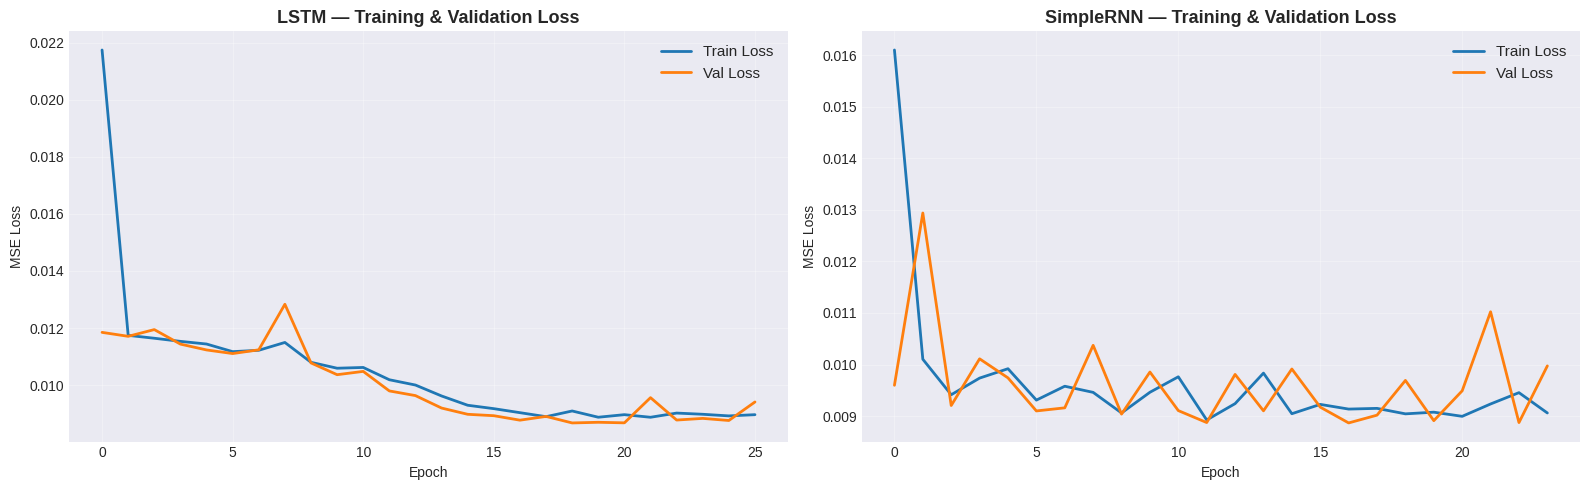

Saved: lstm_loss_curves.png


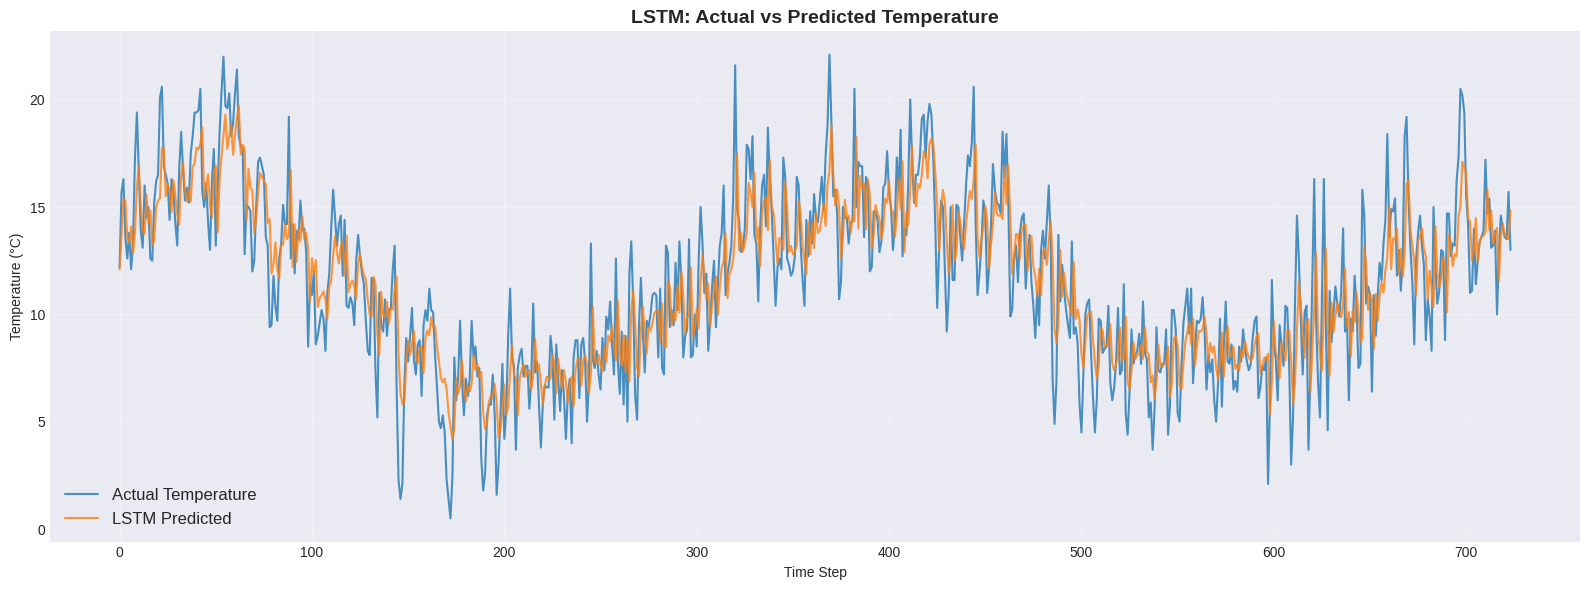

Saved: lstm_actual_vs_predicted.png


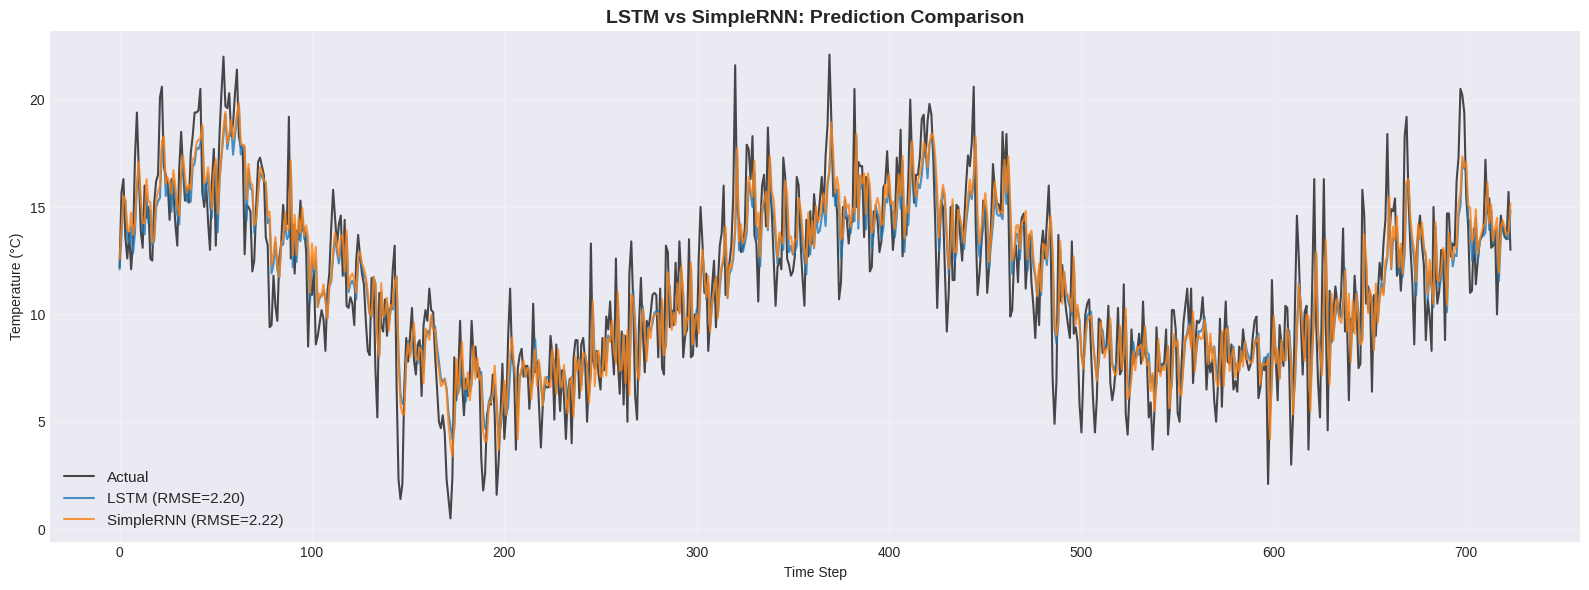

Saved: lstm_vs_rnn_comparison.png


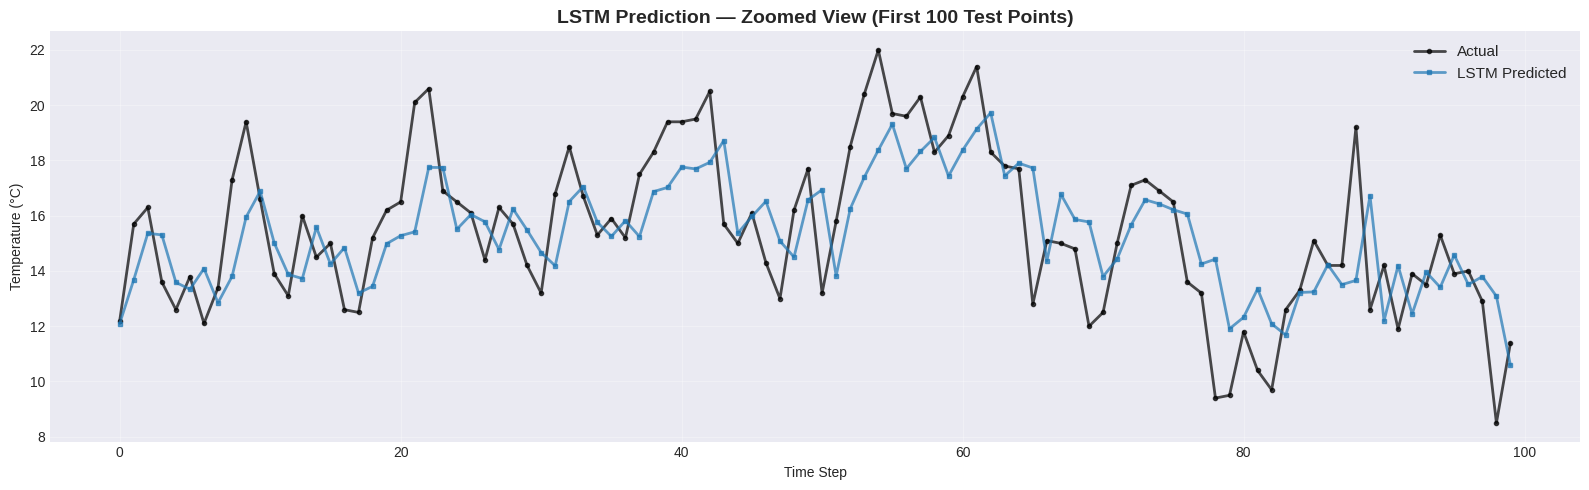

Saved: lstm_zoomed_prediction.png


In [9]:
plt.style.use('seaborn-v0_8-darkgrid')

# -- Plot 1: Training Loss Curves (Both Models) --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('LSTM — Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_rnn.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('SimpleRNN — Training & Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_loss_curves.png"), dpi=150, bbox_inches='tight')
plt.show() # Display the plot
print("Saved: lstm_loss_curves.png")

# -- Plot 2: Actual vs Predicted (LSTM) --
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test_actual, label='Actual Temperature', linewidth=1.5, alpha=0.8)
ax.plot(y_pred_lstm, label='LSTM Predicted', linewidth=1.5, alpha=0.8)
ax.set_title('LSTM: Actual vs Predicted Temperature', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_actual_vs_predicted.png"), dpi=150, bbox_inches='tight')
plt.show() # Display the plot
print("Saved: lstm_actual_vs_predicted.png")

# -- Plot 3: LSTM vs SimpleRNN Predictions --
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test_actual, label='Actual', linewidth=1.5, alpha=0.7, color='black')
ax.plot(y_pred_lstm, label=f'LSTM (RMSE={rmse_lstm:.2f})', linewidth=1.5, alpha=0.8)
ax.plot(y_pred_rnn, label=f'SimpleRNN (RMSE={rmse_rnn:.2f})', linewidth=1.5, alpha=0.8)
ax.set_title('LSTM vs SimpleRNN: Prediction Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_vs_rnn_comparison.png"), dpi=150, bbox_inches='tight')
plt.show() # Display the plot
print("Saved: lstm_vs_rnn_comparison.png")

# -- Plot 4: Zoomed-in Prediction (first 100 test points) --
fig, ax = plt.subplots(figsize=(16, 5))
zoom = min(100, len(y_test_actual))
ax.plot(y_test_actual[:zoom], label='Actual', linewidth=2, marker='o',
        markersize=3, alpha=0.7, color='black')
ax.plot(y_pred_lstm[:zoom], label='LSTM Predicted', linewidth=2, marker='s',
        markersize=3, alpha=0.7)
ax.set_title('LSTM Prediction — Zoomed View (First 100 Test Points)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_zoomed_prediction.png"), dpi=150, bbox_inches='tight')
plt.show() # Display the plot
print("Saved: lstm_zoomed_prediction.png")


--- Testing sequence length: 10 ---
  RMSE: 2.2939, MAE: 1.7968

--- Testing sequence length: 30 ---
  RMSE: 2.2944, MAE: 1.8054

--- Testing sequence length: 60 ---
  RMSE: 2.2380, MAE: 1.7511


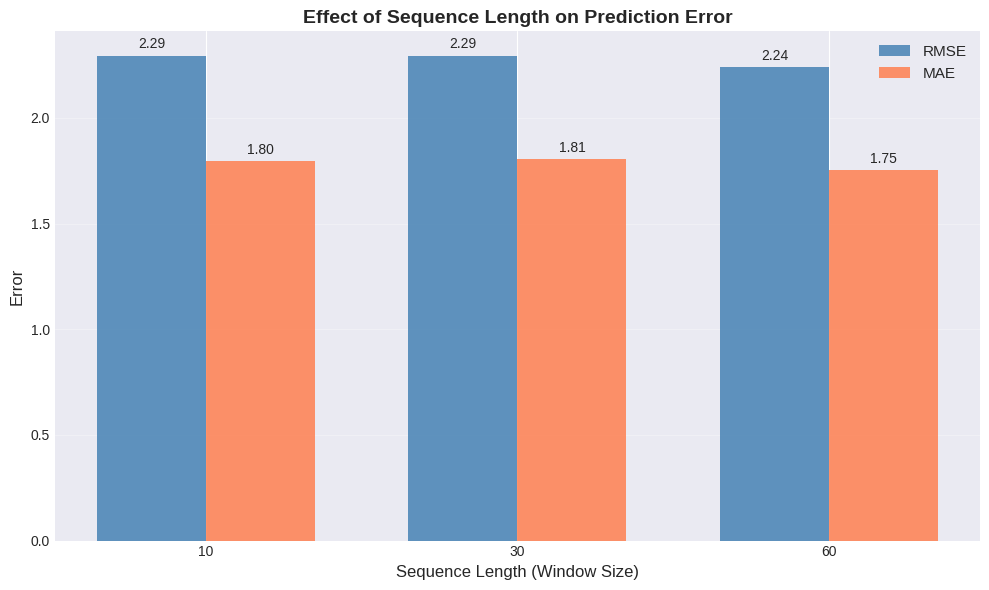


Saved: lstm_sequence_length_comparison.png


In [11]:
# Test different sequence lengths to see their effect
sequence_lengths = [10, 30, 60]
results = {}

for seq_len in sequence_lengths:
    print(f"\n--- Testing sequence length: {seq_len} ---")

    # Create sequences with this window size
    X_seq, y_seq = create_sequences(temperatures_scaled, seq_len)
    split = int(len(X_seq) * 0.8)
    X_tr, X_te = X_seq[:split], X_seq[split:]
    y_tr, y_te = y_seq[:split], y_seq[split:]

    # Build and train a small LSTM
    temp_model = Sequential([
        Input(shape=(seq_len, 1)),
        LSTM(32, name='lstm'),
        Dense(1, name='output')
    ])
    temp_model.compile(optimizer='adam', loss='mse')

    temp_model.fit(
        X_tr, y_tr,
        epochs=20,
        batch_size=32,
        validation_split=0.15,
        verbose=0
    )

    # Evaluate
    y_pred_temp = temp_model.predict(X_te, verbose=0).flatten()
    y_te_inv = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred_temp.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_te_inv, y_pred_inv))
    mae = mean_absolute_error(y_te_inv, y_pred_inv)

    results[seq_len] = {'RMSE': rmse, 'MAE': mae}
    print(f"  RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# -- Plot: Sequence Length Comparison --
fig, ax = plt.subplots(figsize=(10, 6))
seq_lens = list(results.keys())
rmses = [results[s]['RMSE'] for s in seq_lens]
maes = [results[s]['MAE'] for s in seq_lens]

x = np.arange(len(seq_lens))
width = 0.35

bars1 = ax.bar(x - width/2, rmses, width, label='RMSE', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, maes, width, label='MAE', color='coral', alpha=0.85)

ax.set_xlabel('Sequence Length (Window Size)', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Effect of Sequence Length on Prediction Error', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(seq_lens)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_sequence_length_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.show() # Display the plot
print("\nSaved: lstm_sequence_length_comparison.png")